# Run Set Analysis

For each of the 4 `{experiment_type} x {ai_type}` groups (or compared pairs, where noted):
1. A mean ± std comparison, across runs, of 8 metrics (wall time, CPU energy, GPU energy, LLM calls, tokens in, tokens out, tool calls, acceptance rate) between the traditional and agent AI types, one table per experiment_type.
2. The CPU vs. GPU energy split per group.
3. The per-unit outcome breakdown per group (accepted/rejected, and why).

In [ ]:
from great_tables import GT
import matplotlib.pyplot as plt
import polars as pl

from create_polar_dataframe import build_run_level_df, load_all_runs
from plot_style import FONTS, COLOR_PALLETTE


In [3]:
LABELS = {
    'wall_time_seconds': 'Wall Time (seconds)',
    'cpu_energy_joules': 'CPU Energy (Joules)',
    'gpu_energy_joules': 'GPU Energy (Joules)',
    'total_llm_calls': 'Total LLM Calls',
    'total_tokens_in': 'Total Tokens In',
    'total_tokens_out': 'Total Tokens Out',
    'total_tool_calls': 'Total Tool Calls',
    'acceptance_rate': 'Acceptance Rate',
}


In [4]:
run_df_p_t = build_run_level_df(load_all_runs('passive', 'traditional'))
run_df_p_a = build_run_level_df(load_all_runs('passive', 'agent'))
run_df_a_t = build_run_level_df(load_all_runs('active', 'traditional'))
run_df_a_a = build_run_level_df(load_all_runs('active', 'agent'))

In [11]:
def _fmt_sci(x, n_sigfig=3):
    if x is None:
        return "-"
    return f"{x:.{n_sigfig - 1}e}"


def compare_runs_table(named_run_dfs, metrics=None, n_sigfig=3):
    """One row per metric, one column per named run_df, cells as 'mean ± std'."""
    metrics = metrics or list(LABELS.keys())
    rows = []
    for m in metrics:
        row = {'Metric': LABELS[m]}
        for name, run_df in named_run_dfs.items():
            s = run_df[m]
            mean, std = s.mean(), s.std()
            row[name] = (
                f"{_fmt_sci(mean, n_sigfig)} ± {_fmt_sci(std, n_sigfig)}"
                if mean is not None else "-"
            )
        rows.append(row)
    return GT(pl.DataFrame(rows))


## Passive: Traditional vs. Agent

In [12]:
compare_tbl = compare_runs_table({
    'Passive/Traditional': run_df_p_t,
    'Passive/Agent': run_df_p_a,
})
print(compare_tbl.as_latex())
compare_tbl


\begin{table}[!t]


\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lll}
\toprule
Metric & Passive/Traditional & Passive/Agent \\ 
\midrule\addlinespace[2.5pt]
Wall Time (seconds) & 5.16e+03 ± 1.39e+02 & 1.05e+04 ± 5.16e+03 \\
CPU Energy (Joules) & 7.35e+05 ± 2.06e+04 & 1.53e+06 ± 7.51e+05 \\
GPU Energy (Joules) & 2.76e+06 ± 8.16e+04 & 5.99e+06 ± 2.97e+06 \\
Total LLM Calls & 2.89e+02 ± 4.71e+00 & 1.99e+01 ± 3.08e-01 \\
Total Tokens In & 7.27e+05 ± 4.82e+04 & 4.78e+06 ± 8.73e+05 \\
Total Tokens Out & 7.64e+04 ± 2.27e+03 & 8.60e+04 ± 1.20e+04 \\
Total Tool Calls & 0.00e+00 ± 0.00e+00 & 2.91e+02 ± 3.30e+01 \\
Acceptance Rate & 9.93e-01 ± 4.13e-03 & 9.93e-01 ± 1.83e-02 \\
\bottomrule
\end{tabular*}

\end{table}



Metric,Passive/Traditional,Passive/Agent
Wall Time (seconds),5.16e+03 ± 1.39e+02,1.05e+04 ± 5.16e+03
CPU Energy (Joules),7.35e+05 ± 2.06e+04,1.53e+06 ± 7.51e+05
GPU Energy (Joules),2.76e+06 ± 8.16e+04,5.99e+06 ± 2.97e+06
Total LLM Calls,2.89e+02 ± 4.71e+00,1.99e+01 ± 3.08e-01
Total Tokens In,7.27e+05 ± 4.82e+04,4.78e+06 ± 8.73e+05
Total Tokens Out,7.64e+04 ± 2.27e+03,8.60e+04 ± 1.20e+04
Total Tool Calls,0.00e+00 ± 0.00e+00,2.91e+02 ± 3.30e+01
Acceptance Rate,9.93e-01 ± 4.13e-03,9.93e-01 ± 1.83e-02


## Active: Traditional vs. Agent

In [13]:
compare_tbl = compare_runs_table({
    'Active/Traditional': run_df_a_t,
    'Active/Agent': run_df_a_a,
})
print(compare_tbl.as_latex())
compare_tbl


\begin{table}[!t]


\fontsize{12.0pt}{14.4pt}\selectfont

\begin{tabular*}{\linewidth}{@{\extracolsep{\fill}}lll}
\toprule
Metric & Active/Traditional & Active/Agent \\ 
\midrule\addlinespace[2.5pt]
Wall Time (seconds) & 4.50e+03 ± 7.63e+01 & 5.10e+03 ± 1.41e+03 \\
CPU Energy (Joules) & 6.11e+05 ± 1.07e+04 & 7.30e+05 ± 2.04e+05 \\
GPU Energy (Joules) & 2.17e+06 ± 4.15e+04 & 2.84e+06 ± 8.11e+05 \\
Total LLM Calls & 1.31e+02 ± 1.38e+00 & 9.90e+00 ± 3.08e-01 \\
Total Tokens In & 4.71e+05 ± 1.63e+04 & 2.96e+06 ± 5.93e+05 \\
Total Tokens Out & 3.67e+04 ± 7.78e+02 & 4.83e+04 ± 7.04e+03 \\
Total Tool Calls & 0.00e+00 ± 0.00e+00 & 1.66e+02 ± 1.84e+01 \\
Acceptance Rate & 9.76e-01 ± 4.40e-03 & 9.90e-01 ± 3.08e-02 \\
\bottomrule
\end{tabular*}

\end{table}



Metric,Active/Traditional,Active/Agent
Wall Time (seconds),4.50e+03 ± 7.63e+01,5.10e+03 ± 1.41e+03
CPU Energy (Joules),6.11e+05 ± 1.07e+04,7.30e+05 ± 2.04e+05
GPU Energy (Joules),2.17e+06 ± 4.15e+04,2.84e+06 ± 8.11e+05
Total LLM Calls,1.31e+02 ± 1.38e+00,9.90e+00 ± 3.08e-01
Total Tokens In,4.71e+05 ± 1.63e+04,2.96e+06 ± 5.93e+05
Total Tokens Out,3.67e+04 ± 7.78e+02,4.83e+04 ± 7.04e+03
Total Tool Calls,0.00e+00 ± 0.00e+00,1.66e+02 ± 1.84e+01
Acceptance Rate,9.76e-01 ± 4.40e-03,9.90e-01 ± 3.08e-02


## Energy Proportions


In [26]:
def analyze_cpu_vs_gpu_energy(run_df, ax, subtitle):
    cpu_mean = run_df['cpu_energy_joules'].mean()
    gpu_mean = run_df['gpu_energy_joules'].mean()
    total = cpu_mean + gpu_mean

    cpu_color, gpu_color = COLOR_PALLETTE['blue'], COLOR_PALLETTE['orange']
    pct_text_color = 'white'

    with plt.rc_context(FONTS):
        _, _, autotexts = ax.pie(
            [cpu_mean, gpu_mean],
            labels=['CPU Energy', 'GPU Energy'],
            colors=[cpu_color, gpu_color],
            autopct='%1.1f%%',
            startangle=90,
            pctdistance=0.75,
            textprops={'fontsize': 12},
        )

        for at in autotexts:
            at.set_color(pct_text_color)

        ax.axis('equal')

        ax.text(
            0,
            -1.25,
            (
                r'$\mathbf{CPU:}$' f' {cpu_mean:,.0f} J   |   '
                r'$\mathbf{GPU:}$' f' {gpu_mean:,.0f} J   |   '
                r'$\mathbf{Total:}$' f' {total:,.0f} J'
            ),
            ha='center',
            fontsize=10,
            bbox=dict(
                boxstyle='round,pad=0.4',
                facecolor='white',
                edgecolor='black',
                alpha=0.85,
            ),
        )

        ax.set_title(subtitle, fontsize=18, fontweight='bold', fontfamily='Crimson Pro')


### Passive: Traditional vs. Agent

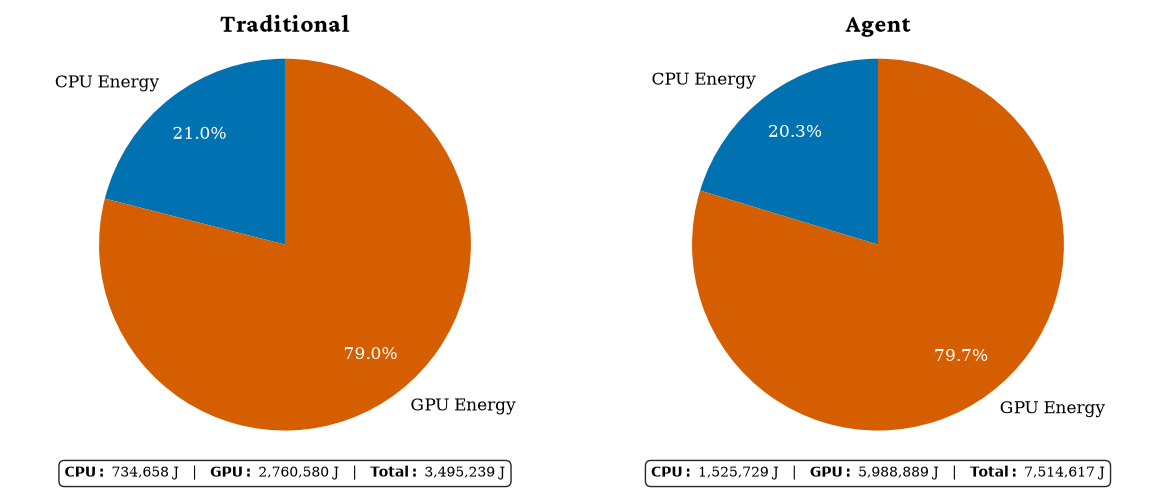

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

analyze_cpu_vs_gpu_energy(run_df_p_t, ax=axes[0], subtitle='Traditional')
analyze_cpu_vs_gpu_energy(run_df_p_a, ax=axes[1], subtitle='Agent')

fig.tight_layout()


### Active: Traditional vs. Agent

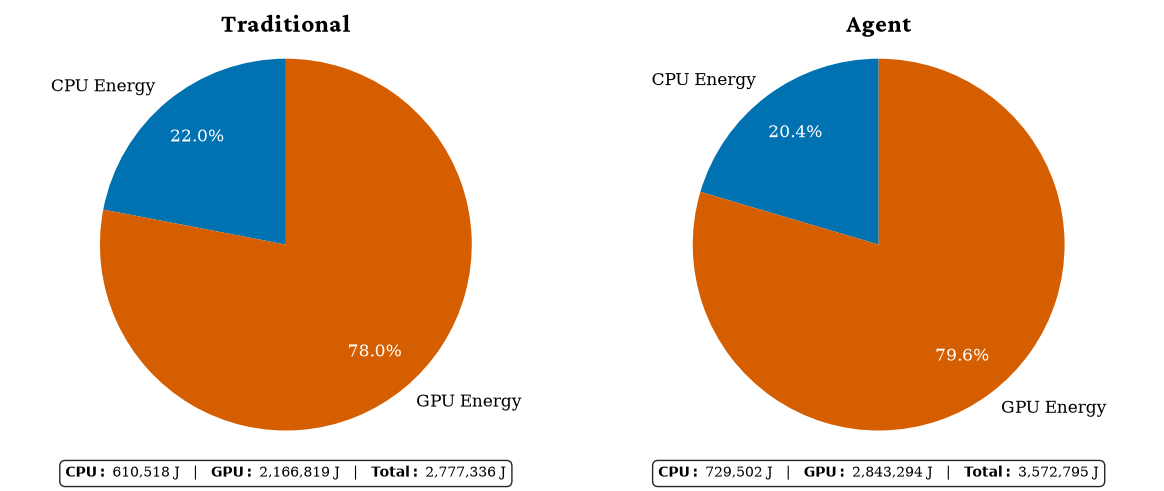

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

analyze_cpu_vs_gpu_energy(run_df_a_t, ax=axes[0], subtitle='Traditional')
analyze_cpu_vs_gpu_energy(run_df_a_a, ax=axes[1], subtitle='Agent')

fig.tight_layout()
